#### Importing Iris data set and getting one sepal length feature column instances for the Iris-setosa target.

In [110]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
iris = fetch_ucirepo(id=53)

df = pd.DataFrame(iris.data.features, columns=iris.data.feature_names)
df['target'] = iris.data.targets

setosa_df = df[df['target'] == 'Iris-virginica'].drop(columns=['target'])

#### Calculating Dependency List

In [111]:
dep_matrix = setosa_df.corr(method='kendall')
print("Dependence Matrix for Iris-Setosa:")
display(dep_matrix.style.background_gradient(cmap='viridis')) # Nice visualization for Jupyter

# 5. Identify the strongest connection to start your D-Vine path
abs_rank = dep_matrix.abs().unstack().sort_values(ascending=False)
abs_rank = abs_rank[abs_rank < 1.0]
print("\nStrongest pairs to place together in Tree 1:")
print(abs_rank.head(4))

Dependence Matrix for Iris-Setosa:


,sepal length,sepal width,petal length,petal width
sepal length,1.000000,0.307087,0.669815,0.218989
sepal width,0.307087,1.000000,0.291282,0.418648
petal length,0.669815,0.291282,1.000000,0.271415
petal width,0.218989,0.418648,0.271415,1.000000



Strongest pairs to place together in Tree 1:
sepal length  petal length    0.669815
petal length  sepal length    0.669815
sepal width   petal width     0.418648
petal width   sepal width     0.418648
dtype: float64


#### Calculating Copulas and BIC Score

In [112]:
import numpy as np
import sys
sys.path.append('../src')  # Adjust path as needed
from copula_families import GaussianCopula, StudentTCopula, ClaytonCopula, transform_to_uniform

def to_uniform(data):
    n = len(data)
    ranks = np.argsort(np.argsort(data)) + 1
    return ranks / (n + 1)

def calculate_copulas(u, v, pairing):
    gaussian = GaussianCopula()
    gaussian.fit(u, v)
    bic_gaussian = gaussian.bic(u, v)

    # Compute Clayton Copula
    clayton = ClaytonCopula()
    clayton.fit(u, v)
    bic_clayton = clayton.bic(u, v)

    # Compute Student T Copula
    student_t = StudentTCopula()
    student_t.fit(u, v)
    bic_student_t = student_t.bic(u, v)
    
    if bic_gaussian <= bic_clayton and bic_gaussian <= bic_student_t:
        print("Gaussian Copula")
    elif bic_clayton < bic_gaussian and bic_clayton < bic_student_t:
        print("Clayton Copula")
    else:
        print("Student T Copula")
    print(pairing, min(bic_gaussian, bic_clayton, bic_student_t))

sepal_len = to_uniform(setosa_df['sepal length'].values)
sepal_width = to_uniform(setosa_df['sepal width'].values)
petal_len = to_uniform(setosa_df['petal length'].values)
petal_width = to_uniform(setosa_df['petal width'].values)

calculate_copulas(petal_len, sepal_len, 'PL-SL')
calculate_copulas(sepal_len, sepal_width, 'SL-SW')
calculate_copulas(petal_width, sepal_width, 'PW-SW')

Gaussian Copula
PL-SL -58.515343590173536
Clayton Copula
SL-SW -6.096945967966974
Gaussian Copula
PW-SW -12.232272056726263


#### Visualizing Copula Selection Graphs

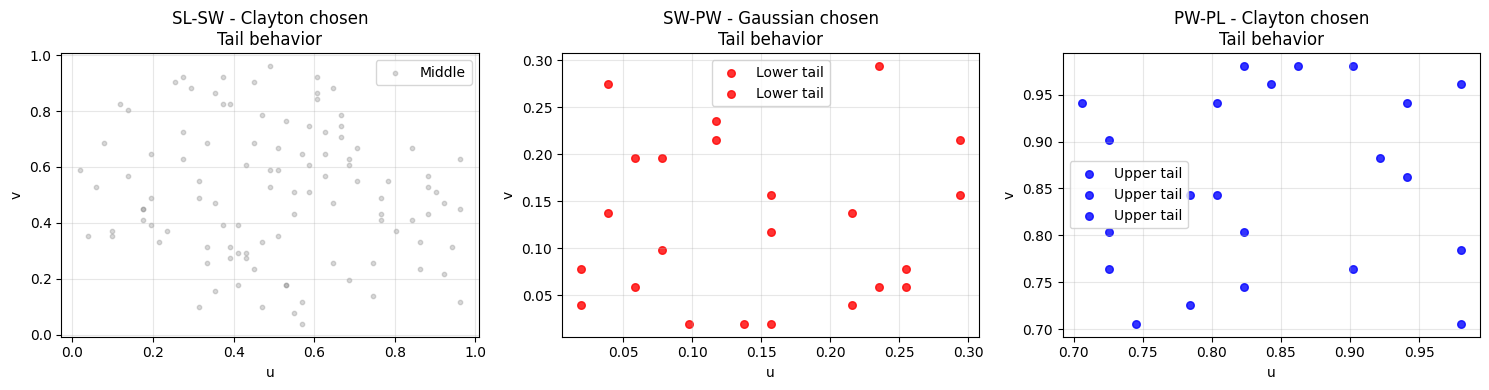

In [113]:
# Simple comparison focusing on why BIC made certain choices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


for i, (u, v, pair_name, best_copula) in enumerate(pairs):
    # # 1. Scatter plot
    # axes[i, 0].scatter(u, v, alpha=0.5, s=20)
    # axes[i, 0].set_title(f'{pair_name}\nData Points')
    # axes[i, 0].set_xlabel('u')
    # axes[i, 0].set_ylabel('v')
    # axes[i, 0].grid(True, alpha=0.3)
    
    # # 2. Histogram of u values
    # axes[i, 1].hist(u, bins=20, alpha=0.7, edgecolor='black')
    # axes[i, 1].set_title(f'Distribution of u\n({pair_name})')
    # axes[i, 1].set_xlabel('u value')
    # axes[i, 1].set_ylabel('Frequency')
    # axes[i, 1].grid(True, alpha=0.3)
    
    # 3. Conditional scatter for tail analysis
    # Points where both u and v are in lower 30%
    mask_lower = (u < 0.3) & (v < 0.3)
    mask_upper = (u > 0.7) & (v > 0.7)
    
    axes[0].scatter(u[~mask_lower & ~mask_upper], v[~mask_lower & ~mask_upper], 
                       alpha=0.3, s=10, color='gray', label='Middle')
    axes[1].scatter(u[mask_lower], v[mask_lower], 
                       alpha=0.8, s=30, color='red', label='Lower tail')
    axes[2].scatter(u[mask_upper], v[mask_upper], 
                       alpha=0.8, s=30, color='blue', label='Upper tail')
    
    axes[i].set_title(f'{pair_name} - {best_copula} chosen\nTail behavior')
    axes[i].set_xlabel('u')
    axes[i].set_ylabel('v')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

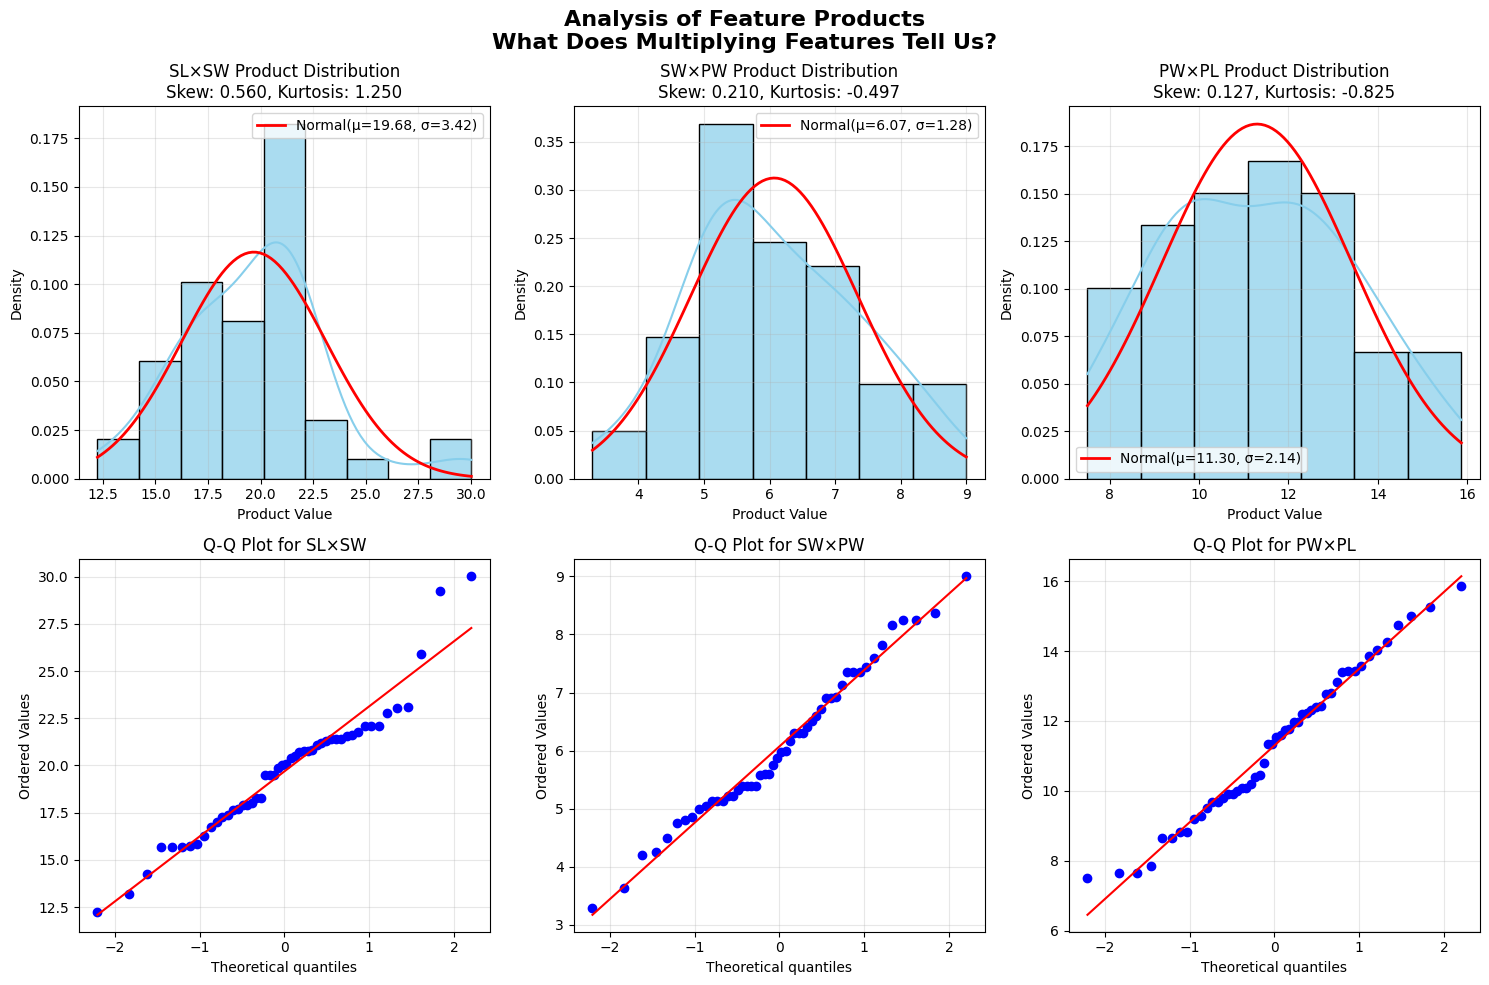

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Use your Iris setosa data
sl = setosa_df['sepal length'].values
sw = setosa_df['sepal width'].values
pl = setosa_df['petal length'].values
pw = setosa_df['petal width'].values

# Multiply the feature pairs from your analysis
products = {
    'SL×SW': sl * sw,  # Clayton pair
    'SW×PW': sw * pw,  # Gaussian pair  
    'PW×PL': pw * pl   # Clayton pair
}

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (name, product) in enumerate(products.items()):
    # 1. Histogram with KDE
    ax1 = axes[0, i]
    sns.histplot(product, kde=True, ax=ax1, stat='density', 
                 color='skyblue', edgecolor='black', alpha=0.7)
    
    # Fit normal distribution
    mu, std = np.mean(product), np.std(product)
    x_range = np.linspace(min(product), max(product), 100)
    normal_pdf = stats.norm.pdf(x_range, mu, std)
    ax1.plot(x_range, normal_pdf, 'r-', linewidth=2, label=f'Normal(μ={mu:.2f}, σ={std:.2f})')
    
    # Calculate skewness and kurtosis
    skewness = stats.skew(product)
    kurtosis = stats.kurtosis(product)
    
    ax1.set_title(f'{name} Product Distribution\n'
                  f'Skew: {skewness:.3f}, Kurtosis: {kurtosis:.3f}')
    ax1.set_xlabel('Product Value')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Q-Q plot (normality test)
    ax2 = axes[1, i]
    stats.probplot(product, dist="norm", plot=ax2)
    ax2.set_title(f'Q-Q Plot for {name}')
    ax2.grid(True, alpha=0.3)

plt.suptitle('Analysis of Feature Products\nWhat Does Multiplying Features Tell Us?', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()